In [1]:
# Создание виртуального окружения 'muon'
!python -m venv muon

# Обновление pip, setuptools и wheel внутри окружения
!./muon/bin/python -m pip install --upgrade pip setuptools wheel

# Установка всех необходимых библиотек одной командой
!./muon/bin/python -m pip install torch torchvision ipykernel matplotlib pandas seaborn

# Установка ядра ipykernel для использования в Jupyter
!./muon/bin/python -m ipykernel install --user --name muon-venv --display-name "Python (muon-venv)"

Installed kernelspec muon-venv in /home/daniilisupov/.local/share/jupyter/kernels/muon-venv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
import time
import inspect
from typing import Optional, List, Dict, Any
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributed as dist
import torchvision
import torchvision.transforms as transforms
import numpy as np

In [3]:
# Ensure torch._linalg_utils is available. This is an internal module,
# but was used in the original _lowrank.py code.
try:
    _utils = torch._linalg_utils
except AttributeError:
    # Fallback for newer versions where it might be removed or changed
    class _LinalgUtils:
        @staticmethod
        def matmul(A, B):
            return torch.matmul(A, B)

        @staticmethod
        def get_floating_dtype(tensor):
            # This is a simplified fallback; actual implementation handles complex types too.
            if tensor.is_floating_point():
                return tensor.dtype
            raise TypeError("Expected a floating point tensor")
    _utils = _LinalgUtils()

In [4]:
num_workers = os.cpu_count() - 2

def configure_cpu():
    """Оптимизирует настройки PyTorch для вычислений на CPU."""
    if torch.cuda.is_available():
        return
    
    # Установка количества потоков для вычислений
    torch.set_num_threads(num_workers or 1)
    torch.set_num_interop_threads(1)
    
    # Включаем MKLDNN для ускорения Conv/Linear операций на CPU
    torch.backends.mkldnn.enabled = True

configure_cpu()

In [5]:
@torch.jit.script
def zeropower_via_newtonschulz5(G: torch.Tensor, steps: int, eps: float = 1e-7) -> torch.Tensor:
    """
    Аппроксимирует ортогональную матрицу U в полярном разложении G = UP
    с помощью пяти итераций Ньютона-Шульца (5-го порядка).
    """
    assert G.ndim >= 2, "Входной тензор должен быть как минимум 2D"
    
    # Коэффициенты для метода 5-го порядка
    a, b, c = (3.4445, -4.7750, 2.0315)

    # Используем float32 на CPU для лучшей производительности
    X = G.float() if G.device.type == "cpu" else G.to(torch.bfloat16)

    # Транспонирование для эффективности, если m > n
    transposed = False
    if X.shape[-2] > X.shape[-1]:
        X = X.mT
        transposed = True

    # Нормализация матрицы
    norm_val = torch.linalg.norm(X, ord='fro', dim=(-2, -1), keepdim=True).clamp_min(eps)
    X = X / norm_val

    # Итерационный процесс
    for _ in range(steps):
        A = X @ X.mT
        X = a * X + (b * A + c * (A @ A)) @ X

    if transposed:
        X = X.mT
        
    return X.to(G.dtype)

In [6]:
def _as_2d_update(t: torch.Tensor) -> torch.Tensor:
    """Вспомогательная функция для преобразования тензора в 2D матрицу."""
    if t.ndim < 2:
        raise ValueError("Muon ожидает тензор с ndim >= 2")
    return t.reshape(t.shape[0], -1) if t.ndim != 2 else t

def muon_polar_update(
    grad: torch.Tensor, 
    momentum: torch.Tensor, 
    beta: float = 0.95, 
    ns_steps: int = 5, 
    nesterov: bool = True
) -> torch.Tensor:
    """
    Вычисляет шаг обновления для Muon с использованием полярного разложения (через Ньютона-Шульца).
    """
    # Обновление моментума
    momentum.lerp_(grad, 1 - beta)
    
    # Применение моментума Нестерова, если указано
    upd = grad.lerp_(momentum, beta) if nesterov else momentum
    
    # Преобразуем в 2D и получаем размеры
    upd2d = _as_2d_update(upd)
    m, n = upd2d.shape[-2:]

    # Ортогонализация с помощью Ньютона-Шульца
    upd2d = zeropower_via_newtonschulz5(upd2d, steps=ns_steps)
    
    # Масштабирующий коэффициент из статьи μP
    upd2d *= (max(1.0, m / n) ** 0.5)

    return upd2d

In [7]:
class MuonSingleDevice(torch.optim.Optimizer):
    """
    Вариант оптимизатора Muon для использования в нераспределенных средах.
    """
    def __init__(self, params, lr=0.02, weight_decay=0, momentum=0.95):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                
                state = self.state[p]
                if not state:
                    state["momentum_buffer"] = torch.zeros_like(p)

                update = muon_polar_update(
                    p.grad, 
                    state["momentum_buffer"], 
                    beta=group["momentum"]
                )

                # Применение weight decay и шага обновления
                p.mul_(1 - group["lr"] * group["weight_decay"])
                p.add_(update.reshape(p.shape), alpha=-group["lr"])

        return loss

In [8]:
def randomized_range_finder(
    A: torch.Tensor,
    q: int,
    niter: int = 2,
    M: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """
    Находит ортогональную матрицу Q, столбцы которой аппроксимируют базис
    пространства столбцов матрицы A, используя рандомизированный алгоритм.
    """
    if A.ndim != 2:
        raise ValueError(f"Ожидалась 2D матрица, получена {A.ndim}D")

    A32 = A.float()
    matmul = _utils.matmul

    m, n = A32.shape
    R = torch.randn(n, q, dtype=A32.dtype, device=A32.device)

    if M is not None:
        M32 = M.float()
        X = matmul(A32, R) - matmul(M32, R)
    else:
        X = matmul(A32, R)

    # Используем уникальное имя для игнорируемой переменной
    Q, _R_ignored = torch.linalg.qr(X, mode="reduced")
    
    for i in range(niter):
        if M is not None:
            M32_inner = M.float()
            X = matmul(A32.mT, Q) - matmul(M32_inner.mT, Q)
        else:
            X = matmul(A32.mT, Q)
        # Снова используем уникальное имя
        Q, _R_ignored_inner = torch.linalg.qr(X, mode="reduced")

        if M is not None:
            M32_inner = M.float()
            X = matmul(A32, Q) - matmul(M32_inner, Q)
        else:
            X = matmul(A32, Q)
        Q, _R_ignored_inner2 = torch.linalg.qr(X, mode="reduced")

    return Q

In [9]:
@torch.jit.script
def lowrank_polar_update_via_range_and_ns(
    A: torch.Tensor,
    q: int = 6,
    niter: int = 2,
    steps: int = 5
) -> torch.Tensor:
    """
    Низкоранговая аппроксимация ортогональной матрицы U в полярном разложении A.
    Использует randomized_range_finder и Newton-Schulz на матрице меньшей размерности.
    """
    q_rank = min(q, A.shape[-2], A.shape[-1])
    orig_dtype = A.dtype
    A32 = A.float()
    matmul = _utils.matmul
    
    # 1. Находим приближенный базис для A
    Q = randomized_range_finder(A32, q_rank, niter=niter)
    
    # 2. Проецируем A на этот базис
    B = matmul(Q.mH, A32)
    
    # 3. Ортогонализуем меньшую матрицу B
    B_orth = zeropower_via_newtonschulz5(B, steps=steps)
    
    # 4. Реконструируем ортогональную матрицу исходного размера
    reconstructed_A = matmul(Q, B_orth)

    return reconstructed_A.to(orig_dtype)

In [10]:
def muon_lowrank_polar_update_ns(
    grad: torch.Tensor, 
    momentum: torch.Tensor, 
    k: int = 6, 
    beta: float = 0.95, 
    ns_steps: int = 5, 
    nesterov: bool = True
) -> torch.Tensor:
    """Шаг обновления Muon с использованием низкоранговой аппроксимации и Ньютона-Шульца."""
    # Обновление моментума
    momentum.lerp_(grad, 1 - beta)
    update = grad.lerp_(momentum, beta) if nesterov else momentum

    # Преобразование для Conv слоев
    if update.ndim == 4:
        update = update.reshape(update.shape[0], -1)

    # Низкоранговое обновление с реконструкцией
    update = lowrank_polar_update_via_range_and_ns(update, q=k, steps=ns_steps)

    # Масштабирующий коэффициент μP
    m, n = update.shape
    scale = (max(1.0, m / n) ** 0.5)
    update = update * scale

    return update

In [11]:
class MuonLowRankNSOptimizer(torch.optim.Optimizer):
    """
    Вариант Muon, использующий рандомизированное SVD для ортогонализации,
    с последующим применением Ньютона-Шульца к матрице меньшей размерности и реконструкцией.
    """
    def __init__(self, params, lr=0.02, weight_decay=0, momentum=0.95, k=6, ns_steps=5):
        """
        k:      Целевой ранг для низкоранговой аппроксимации.
        ns_steps: Количество шагов Ньютона-Шульца.
        """
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum, k=k, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            k = group["k"]
            ns_steps = group["ns_steps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                
                state = self.state[p]
                if not state:
                    state["momentum_buffer"] = torch.zeros_like(p)

                update = muon_lowrank_polar_update_ns(
                    p.grad, 
                    state["momentum_buffer"],
                    k=k, 
                    beta=group["momentum"],
                    ns_steps=ns_steps, 
                    nesterov=True
                )

                p.mul_(1 - group["lr"] * group["weight_decay"])
                p.add_(update.reshape(p.shape), alpha=-group["lr"])

        return loss

In [12]:
@torch.jit.script
def adam_update(
    grad: torch.Tensor, 
    buf1: torch.Tensor, 
    buf2: torch.Tensor, 
    step: int,                  # <- Явно указываем int
    betas: List[float],         # <- Явно указываем List[float]
    eps: float                  # <- Явно указываем float
) -> torch.Tensor:
    """Стандартный шаг обновления для Adam."""
    beta1, beta2 = betas[0], betas[1]
    
    buf1.lerp_(grad, 1 - beta1)
    buf2.lerp_(grad.square(), 1 - beta2)
    # Коррекция смещения
    bias_correction1 = 1.0 - beta1 ** step
    bias_correction2 = 1.0 - beta2 ** step

    buf1c = buf1 / bias_correction1
    buf2c = buf2 / bias_correction2
    return buf1c / (buf2c.sqrt() + eps)


class MuonWithAuxAdamSingleDevice(torch.optim.Optimizer):
    """
    Гибридный оптимизатор для одного устройства.
    Применяет Muon к матричным весам и AdamW к остальным параметрам (смещения, BatchNorm и т.д.).
    Это упрощает код обучения, так как не требуется создавать и шагать два разных оптимизатора.
    """
    def __init__(self, param_groups: List[Dict[str, Any]]):
        for group in param_groups:
            assert "use_muon" in group, "Каждая группа параметров должна иметь флаг 'use_muon'."
            
            if group["use_muon"]:
                group.setdefault("lr", 0.02)
                group.setdefault("momentum", 0.95)
                group.setdefault("weight_decay", 0.0)
            else: # Adam
                group.setdefault("lr", 3e-4)
                group.setdefault("betas", (0.9, 0.95))
                group.setdefault("eps", 1e-10)
                group.setdefault("weight_decay", 0.0)
                
        super().__init__(param_groups, dict())
    
    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                
                state = self.state[p]
                
                if group["use_muon"]:
                    # --- Логика Muon ---
                    if not state:
                        state["momentum_buffer"] = torch.zeros_like(p)
                    
                    update = muon_polar_update(p.grad, state["momentum_buffer"], beta=group["momentum"])
                    
                    p.mul_(1 - group["lr"] * group["weight_decay"])
                    p.add_(update.reshape(p.shape), alpha=-group["lr"])
                else:
                    # --- Логика AdamW ---
                    if not state:
                        state["step"] = 0
                        state["exp_avg"] = torch.zeros_like(p)
                        state["exp_avg_sq"] = torch.zeros_like(p)
                    
                    state["step"] += 1
                    betas_list = list(group["betas"])
                    
                    update = adam_update(
                        p.grad, state["exp_avg"], state["exp_avg_sq"],
                        state["step"], betas_list, group["eps"]
                    )
                    
                    p.mul_(1 - group["lr"] * group["weight_decay"])
                    p.add_(update, alpha=-group["lr"])
        return loss

In [13]:
class SimpleCNN(nn.Module):
    """Простая сверточная нейронная сеть для классификации изображений."""
    def __init__(self, num_classes=10, in_channels=3, img_size=32):
        super().__init__()
        # Первый сверточный блок
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Второй сверточный блок
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.25)

        # Вычисление размера для полносвязных слоев
        feat_size = img_size // 4  # Два пулинга 2x2
        self.fc1 = nn.Linear(64 * feat_size * feat_size, 512)

        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        x = x.flatten(1)
        x = self.dropout1(x)
        
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        
        return x

In [14]:
@torch.jit.script
def polar_orthogonalize_rsvd(G: torch.Tensor, k: int, niter_rsvd: int = 2) -> torch.Tensor:
    """
    Низкоранговая аппроксимация ортогональной матрицы U в полярном разложении G
    с помощью рандомизированного SVD.
    """
    assert G.ndim >= 2
    m, n = G.shape[-2:]
    k = min(k, m, n)

    if k == 0:
        return torch.zeros_like(G)

    orig_dtype = G.dtype
    G32 = G.float()

    # 1. Находим приближенный базис Q
    Q = randomized_range_finder(G32, k, niter=niter_rsvd)
    
    # 2. Проецируем G на Q
    B = _utils.matmul(Q.mH, G32)
    
    # 3. Выполняем SVD для меньшей матрицы B
    U_B, _, Vh_B = torch.linalg.svd(B, full_matrices=False)
    
    # 4. Реконструируем ортогональную матрицу, заменяя сингулярные значения на 1 (U_B @ Vh_B)
    reconstructed_G = _utils.matmul(_utils.matmul(Q, U_B), Vh_B)

    return reconstructed_G.to(orig_dtype)

In [15]:
def muon_lowrank_polar_update_rsvd(
    grad: torch.Tensor, 
    momentum: torch.Tensor, 
    k: int, 
    niter_rsvd: int = 2, 
    beta: float = 0.95, 
    nesterov: bool = True
) -> torch.Tensor:
    """
    Шаг обновления Muon с использованием низкорангового полярного разложения
    через рандомизированное SVD (аппроксимация U = G(G^T G)^{-1/2} через U V^T).
    """
    # Обновление моментума
    momentum.lerp_(grad, 1 - beta)
    update = grad.lerp_(momentum, beta) if nesterov else momentum

    original_shape = update.shape
    if update.ndim == 4:
        update = update.reshape(update.shape[0], -1)

    # Низкоранговая ортогонализация
    update = polar_orthogonalize_rsvd(update, k=k, niter_rsvd=niter_rsvd)

    # Масштабирующий коэффициент μP
    m, n = update.shape
    update *= (max(1.0, m / n) ** 0.5)

    return update.reshape(original_shape)

In [16]:
class HybridMuonAdamOptimizer(torch.optim.Optimizer):
    """
    Гибкий гибридный оптимизатор, позволяющий использовать разные функции обновления для Muon
    (полноранговый, низкоранговый NS, низкоранговый RSVD) и AdamW для остальных параметров.
    """
    def __init__(self, param_groups: List[Dict[str, Any]]):
        for group in param_groups:
            assert "use_muon" in group
            
            if group["use_muon"]:
                group.setdefault("lr", 0.02)
                group.setdefault("momentum", 0.95)
                group.setdefault("weight_decay", 0.0)
                group.setdefault("muon_update_fn", muon_polar_update)
                # Параметры для разных update-функций
                group.setdefault("muon_k", 6)
                group.setdefault("muon_ns_steps", 5)
                group.setdefault("muon_niter_rsvd", 2)
            else: # Adam
                group.setdefault("lr", 3e-4)
                group.setdefault("betas", (0.9, 0.95))
                group.setdefault("eps", 1e-10)
                group.setdefault("weight_decay", 0.0)

        super().__init__(param_groups, dict())

    def _call_muon_update(self, fn, grad, momentum_buf, group):
        """Вызывает нужную Muon-функцию с правильными аргументами."""
        candidate_kwargs = {
            "beta": group.get("momentum", 0.95),
            "ns_steps": group.get("muon_ns_steps", 5),
            "k": group.get("muon_k", 6),
            "niter_rsvd": group.get("muon_niter_rsvd", 2),
            "nesterov": True,
        }
        
        # Интроспекция, чтобы передать только те аргументы, которые принимает функция
        sig = inspect.signature(fn)
        kwargs = {k: v for k, v in candidate_kwargs.items() if k in sig.parameters}
        
        return fn(grad, momentum_buf, **kwargs)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]

                if group["use_muon"]:
                    if not state:
                        state["momentum_buffer"] = torch.zeros_like(p)
                    
                    update_fn = group["muon_update_fn"]
                    update = self._call_muon_update(update_fn, p.grad, state["momentum_buffer"], group)
                    
                    p.mul_(1 - group["lr"] * group["weight_decay"])
                    p.add_(update.reshape(p.shape), alpha=-group["lr"])
                else: 
                    if not state:
                        state["step"] = 0
                        state["exp_avg"] = torch.zeros_like(p)
                        state["exp_avg_sq"] = torch.zeros_like(p)
                    
                    state["step"] += 1
                    betas_list = list(group["betas"])
                    
                    update = adam_update(
                        p.grad, state["exp_avg"], state["exp_avg_sq"],
                        state["step"], betas_list, group["eps"]
                    )
                    
                    p.mul_(1 - group["lr"] * group["weight_decay"])
                    p.add_(update, alpha=-group["lr"])
        return loss

In [17]:
def find_latest_checkpoint(checkpoint_dir: str, optimizer_name: str) -> Optional[str]:
    """
    Ищет самый свежий чекпоинт для данного оптимизатора в указанной директории.
    Имена файлов должны иметь формат 'epoch_{epoch_num}_...'.
    """
    optimizer_checkpoint_path = os.path.join(checkpoint_dir, optimizer_name)
    if not os.path.exists(optimizer_checkpoint_path):
        return None

    checkpoints = []
    for f_name in os.listdir(optimizer_checkpoint_path):
        match = re.match(r'epoch_(\d+)_.*\.pth', f_name)
        if match:
            epoch_num = int(match.group(1))
            full_path = os.path.join(optimizer_checkpoint_path, f_name)
            checkpoints.append((epoch_num, full_path))

    if not checkpoints:
        return None

    # Сортируем по номеру эпохи и возвращаем самый новый
    checkpoints.sort(key=lambda x: x[0], reverse=True)
    return checkpoints[0][1]

In [18]:
def evaluate_model(model: nn.Module, test_loader: torch.utils.data.DataLoader, device: torch.device) -> float:
    """Оценивает точность модели на тестовом наборе данных."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [19]:
def save_checkpoint(state: Dict[str, Any], is_best: bool, checkpoint_dir: str, optimizer_name: str):
    """
    Сохраняет состояние модели. Если модель лучшая, сохраняет ее отдельно.
    """
    optimizer_specific_dir = os.path.join(checkpoint_dir, optimizer_name)
    os.makedirs(optimizer_specific_dir, exist_ok=True)

    # Сохраняем текущий чекпоинт
    epoch_filename = f"epoch_{state['epoch'] + 1}_acc_{state['test_accuracy']:.2f}.pth"
    torch.save(state, os.path.join(optimizer_specific_dir, epoch_filename))

    # Если это лучшая модель, сохраняем ее отдельно с другим именем
    if is_best:
        # Сначала удаляем старые "лучшие" файлы, чтобы не засорять диск
        for f_name in os.listdir(optimizer_specific_dir):
            if f_name.startswith("best_model_"):
                os.remove(os.path.join(optimizer_specific_dir, f_name))
        
        best_filename = f"best_model_acc_{state['test_accuracy']:.2f}_epoch_{state['epoch'] + 1}.pth"
        best_path = os.path.join(optimizer_specific_dir, best_filename)
        torch.save(state, best_path)
        print(f"  --> Сохранена новая лучшая модель: {best_path}")

In [20]:
def _print_hyperparameters(optimizer: torch.optim.Optimizer, optimizer_name: str, epochs: int, device: torch.device, use_amp: bool):
    """Красиво выводит конфигурацию эксперимента."""
    print("-" * 60)
    print(f"Эксперимент: {optimizer_name}")
    print(f"Устройство: {device} | Эпохи: {epochs} | AMP: {use_amp}")
    print("-" * 60)
    
    for i, group in enumerate(optimizer.param_groups):
        group_type = "Muon" if group.get("use_muon", False) else "Adam/SGD"
        print(f"  Группа параметров #{i+1} ({group_type}):")
        
        lr = group['lr']
        wd = group.get('weight_decay', 0.0)
        print(f"    Learning Rate: {lr:<10} | Weight Decay: {wd}")

        if group_type == "Muon":
            momentum = group.get('momentum', 'N/A')
            fn_name = group.get('muon_update_fn', muon_polar_update).__name__
            print(f"    Momentum:      {momentum:<10} | Update Fn:    {fn_name}")
            if "lowrank" in fn_name:
                k = group.get('muon_k', 'N/A')
                print(f"    Низкий ранг k: {k}")
            if "ns" in fn_name:
                ns_steps = group.get('muon_ns_steps', 'N/A')
                print(f"    Шаги N-S:      {ns_steps}")
            if "rsvd" in fn_name:
                niter = group.get('muon_niter_rsvd', 'N/A')
                print(f"    Итерации RSVD: {niter}")
        else: # Adam/SGD
            momentum = group.get('momentum')
            betas = group.get('betas')
            if momentum is not None:
                 print(f"    Momentum:      {momentum}")
            if betas is not None:
                print(f"    Betas:         {betas}")
    print("-" * 60)


def train_model(
    model: nn.Module, optimizer: torch.optim.Optimizer, criterion: nn.Module,
    train_loader, test_loader, device: torch.device, epochs: int,
    optimizer_name: str, checkpoint_dir: str, use_amp: bool = True,
    eval_every: int = 1,          # <- оценка раз в N эпох
    save_every: int = 1,          # <- сохранение раз в N эпох
    profile_steps: int = 0        # <- если >0, то печатать среднее по шагам (без шума)
) -> Dict[str, List[float]]:

    _print_hyperparameters(optimizer, optimizer_name, epochs, device, use_amp)

    history = {
        'loss': [], 'accuracy': [], 'test_accuracy': [],
        'avg_step_time_per_epoch': [], 'epoch_time': [],
        # новые метрики:
        't_data': [], 't_fwd': [], 't_bwd': [], 't_opt': [], 't_eval': [], 't_ckpt': []
    }

    start_epoch = 0
    best_test_acc = 0.0

    latest_checkpoint_path = find_latest_checkpoint(checkpoint_dir, optimizer_name)
    if latest_checkpoint_path:
        print(f"Загрузка чекпоинта для '{optimizer_name}' из {latest_checkpoint_path}...")
        checkpoint = torch.load(latest_checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_test_acc = checkpoint.get('best_test_acc', 0.0)
        history = checkpoint.get('history', history)
        print(f"  Возобновление с эпохи {start_epoch}, лучшая точность {best_test_acc:.2f}%")

    scaler = torch.amp.GradScaler(device.type, enabled=(use_amp and device.type == "cuda"))

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0
        correct_predictions, total_samples = 0, 0

        # таймеры эпохи
        t_data = t_fwd = t_bwd = t_opt = 0.0
        step_times = []
        epoch_start = time.perf_counter()

        # чтобы уменьшить шум, можно ограничить профилируемые шаги
        max_steps = profile_steps if profile_steps and profile_steps > 0 else None

        it = iter(train_loader)
        step_idx = 0
        while True:
            if max_steps is not None and step_idx >= max_steps:
                break

            # замер времени получения батча
            t0 = time.perf_counter()
            try:
                inputs, labels = next(it)
            except StopIteration:
                break
            # перенос на device
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            t_data += time.perf_counter() - t0

            step_start = time.perf_counter()
            optimizer.zero_grad(set_to_none=True)

            # forward
            t0 = time.perf_counter()
            use_amp = (device.type == "cuda")
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            t_fwd += time.perf_counter() - t0

            # backward
            t0 = time.perf_counter()
            if scaler.is_enabled():
                scaler.scale(loss).backward()
            else:
                loss.backward()
            t_bwd += time.perf_counter() - t0

            # optimizer step
            t0 = time.perf_counter()
            if scaler.is_enabled():
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            t_opt += time.perf_counter() - t0

            step_times.append(time.perf_counter() - step_start)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            step_idx += 1

        # метрики train
        epoch_loss = running_loss / max(1, step_idx)
        epoch_accuracy = 100 * correct_predictions / max(1, total_samples)
        avg_step_time = float(np.mean(step_times)) if step_times else 0.0

        # eval отдельно
        t_eval = 0.0
        do_eval = (eval_every > 0 and ((epoch + 1) % eval_every == 0))
        if do_eval:
            t0 = time.perf_counter()
            test_acc = evaluate_model(model, test_loader, device)
            t_eval = time.perf_counter() - t0
        else:
            test_acc = history['test_accuracy'][-1] if history['test_accuracy'] else 0.0

        # checkpoint отдельно
        t_ckpt = 0.0
        do_save = (save_every > 0 and ((epoch + 1) % save_every == 0))
        is_best = False
        if do_save:
            is_best = test_acc > best_test_acc
            if is_best:
                best_test_acc = test_acc

            checkpoint_data = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_test_acc': best_test_acc,
                'test_accuracy': test_acc,
                'history': history,
            }
            t0 = time.perf_counter()
            save_checkpoint(checkpoint_data, is_best, checkpoint_dir, optimizer_name)
            t_ckpt = time.perf_counter() - t0
        else:
            if test_acc > best_test_acc:
                best_test_acc = test_acc

        epoch_total = time.perf_counter() - epoch_start

        # логирование
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_accuracy)
        history['test_accuracy'].append(test_acc)
        history['avg_step_time_per_epoch'].append(avg_step_time)
        history['epoch_time'].append(epoch_total)

        history['t_data'].append(t_data)
        history['t_fwd'].append(t_fwd)
        history['t_bwd'].append(t_bwd)
        history['t_opt'].append(t_opt)
        history['t_eval'].append(t_eval)
        history['t_ckpt'].append(t_ckpt)

        print(
            f"Эпоха {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | "
            f"Train Acc: {epoch_accuracy:.2f}% | Test Acc: {test_acc:.2f}% | "
            f"Epoch: {epoch_total:.2f}s | "
            f"data {t_data:.2f}s | fwd {t_fwd:.2f}s | bwd {t_bwd:.2f}s | opt {t_opt:.2f}s | "
            f"eval {t_eval:.2f}s | ckpt {t_ckpt:.2f}s"
        )

    return history

In [21]:
def make_fast_subset(dataset, max_samples: int, seed: int = 0):
    """Создает подвыборку из датасета для ускоренного тестирования."""
    if max_samples >= len(dataset):
        return dataset
    g = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=g)[:max_samples].tolist()
    return torch.utils.data.Subset(dataset, indices)

def build_dataloaders(
    dataset_name: str, 
    fast: bool, 
    batch_size: int, 
    num_workers: int = num_workers,
    device: torch.device = torch.device("cpu"),
    veryfast: bool = False
):
    """Создает загрузчики данных для CIFAR10, MNIST или STL10 с аугментациями."""
    dataset_name = dataset_name.lower()
    data_root = './data'

    if dataset_name == "cifar10":
        transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])
        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])
        trainset = torchvision.datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_train)
        testset = torchvision.datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform_test)
        in_channels, img_size, num_classes = 3, 32, 10

    elif dataset_name == "mnist":
        transform = transforms.Compose([
            transforms.RandomCrop(28, padding=2),
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
        ])
        trainset = torchvision.datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
        testset = torchvision.datasets.MNIST(root=data_root, train=False, download=True, transform=transform)
        in_channels, img_size, num_classes = 1, 28, 10
        
    elif dataset_name == "stl10":
        transform_train = transforms.Compose([
            transforms.RandomCrop(96, padding=8),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713)),
        ])
        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713)),
        ])
        trainset = torchvision.datasets.STL10(root=data_root, split="train", download=True, transform=transform_train)
        testset = torchvision.datasets.STL10(root=data_root, split="test", download=True, transform=transform_test)
        in_channels, img_size, num_classes = 3, 96, 10
        
    else:
        raise ValueError(f"Неизвестный датасет: {dataset_name}")

    if fast:
        trainset = make_fast_subset(trainset, max_samples=10_000, seed=0)
        testset = make_fast_subset(testset, max_samples=2_000, seed=1)
    if veryfast:
        trainset = make_fast_subset(trainset, max_samples=2048, seed=0) # например, всего 2К примеров
        testset = make_fast_subset(testset, max_samples=512, seed=1)   # и 500 для теста

    loader_kwargs = {
        "num_workers": num_workers,
        "pin_memory": device.type == "cuda",
        "persistent_workers": num_workers > 0,
    }

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, **loader_kwargs)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size*2, shuffle=False, **loader_kwargs)

    return train_loader, test_loader, in_channels, img_size, num_classes

In [22]:
def plot_results(results: Dict[str, Dict[str, List[float]]], title_prefix: str = "Сравнение оптимизаторов"):
    """Строит графики метрик обучения для разных экспериментов."""
    plt.figure(figsize=(16, 12))
    plt.suptitle(title_prefix, fontsize=16)

    metrics_to_plot = {
        'loss': ('Loss', 'Training Loss'),
        'accuracy': ('Accuracy (%)', 'Training Accuracy'),
        'test_accuracy': ('Accuracy (%)', 'Test Accuracy'),
        'epoch_time': ('Time (s)', 'Epoch Time')
    }
    
    for i, (metric, (ylabel, title)) in enumerate(metrics_to_plot.items()):
        plt.subplot(2, 2, i + 1)
        for name, history in results.items():
            
            y_values = history.get(metric)
            if not y_values:
                continue

            # Добавляем среднее время эпохи в легенду для информативности
            avg_epoch_time = np.mean(history.get('epoch_time', [0]))
            label = f"{name} (Avg Epoch: {avg_epoch_time:.2f}s)"
            
            epochs_ran = range(1, len(y_values) + 1)
            plt.plot(epochs_ran, y_values, label=label, marker='o', markersize=4, alpha=0.8)
        
        plt.title(title)
        plt.xlabel('Эпоха')
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [23]:
def separate_model_parameters(model: nn.Module, verbose: bool = True) -> (List[nn.Parameter], List[nn.Parameter]):
    """
    Разделяет параметры модели на две группы: для Muon и для Adam.
    - Muon: веса скрытых слоёв (Conv, FC) с размерностью >= 2D.
    - Adam: всё остальное (веса слоя-классификатора, смещения, BatchNorm и т.д.).
    """
    muon_params, adam_params = [], []
    stats = {'muon': {'tensors': 0, 'numel': 0}, 'adam': {'tensors': 0, 'numel': 0}}

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        is_matrix = p.ndim >= 2
        # Скрытые слои для Muon (все, кроме последнего fc)
        is_hidden_weight = name.endswith(".weight") and not name.startswith("fc2.")
        use_muon = is_matrix and is_hidden_weight

        group = 'muon' if use_muon else 'adam'
        stats[group]['tensors'] += 1
        stats[group]['numel'] += p.numel()
        
        if use_muon:
            muon_params.append(p)
        else:
            adam_params.append(p)

    if verbose:
        total_tensors = stats['muon']['tensors'] + stats['adam']['tensors']
        total_numel = stats['muon']['numel'] + stats['adam']['numel']
        
        mu_t_pct = 100 * stats['muon']['tensors'] / total_tensors
        ad_t_pct = 100 * stats['adam']['tensors'] / total_tensors
        mu_n_pct = 100 * stats['muon']['numel'] / total_numel
        ad_n_pct = 100 * stats['adam']['numel'] / total_numel

        print("--- Распределение параметров (Muon vs Adam) ---")
        print(f"  Тензоры: Muon {stats['muon']['tensors']} ({mu_t_pct:.1f}%), Adam {stats['adam']['tensors']} ({ad_t_pct:.1f}%)")
        print(f"  Параметры: Muon {stats['muon']['numel']:,} ({mu_n_pct:.2f}%), Adam {stats['adam']['numel']:,} ({ad_n_pct:.2f}%)")

    return muon_params, adam_params

In [24]:
def plot_stacked_time_per_stage(
    all_results: Dict[str, Dict[str, List[float]]],
    optimizers_to_plot: List[str],
    dataset_name_for_titles: str,
    overall_title_suffix: str
):
    stages = ['t_data', 't_fwd', 't_bwd', 't_opt', 't_eval', 't_ckpt']
    
    ordered_plot_data = []
    added_full_names = set() 
    
    for desired_opt_base_name in optimizers_to_plot:
        found_for_this_base_name = False
        for full_result_name, history_data in all_results.items():
            clean_opt_name = full_result_name.replace(f"{dataset_name_for_titles}_", "")

            if clean_opt_name == desired_opt_base_name and full_result_name not in added_full_names:
                ordered_plot_data.append((full_result_name, history_data))
                added_full_names.add(full_result_name)
                found_for_this_base_name = True
                break 
        
        if not found_for_this_base_name:
            print(f"Предупреждение: Оптимизатор '{desired_opt_base_name}' не найден в результатах для построения графика.")

    if not ordered_plot_data:
        print(f"Нет данных для отображения для {overall_title_suffix} после фильтрации по оптимизаторам.")
        return

    num_plots = len(ordered_plot_data)
    
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
    if num_plots == 1:
        axes = [axes]
    
    fig.suptitle(f"Распределение времени этапов за эпоху ({overall_title_suffix})", fontsize=16)

    all_stage_labels = []
    
    for ax_idx, (optimizer_name, history) in enumerate(ordered_plot_data): 
        
        plot_data = []
        for epoch_idx in range(len(history['epoch_time'])):
            epoch_total_time = history['epoch_time'][epoch_idx]
            
            if epoch_total_time < 0.001: 
                continue 
            
            sum_profiled_stages_time = sum(history[stage][epoch_idx] for stage in stages)

            current_normalization_factor = sum_profiled_stages_time if sum_profiled_stages_time > 1e-6 else epoch_total_time

            for stage in stages:
                time_s = history[stage][epoch_idx]
                percentage = (time_s / current_normalization_factor) * 100 if current_normalization_factor > 0 else 0
                plot_data.append({
                    'Эпоха': epoch_idx + 1,
                    'Этап': stage.replace('t_', ''),
                    'Процент времени': percentage,
                    'Общее время эпохи (с)': epoch_total_time
                })
        
        df = pd.DataFrame(plot_data)
        
        clean_optimizer_name = optimizer_name.replace(f"{dataset_name_for_titles}_", "") 

        if df.empty:
            axes[ax_idx].set_title(f"{clean_optimizer_name}\n(Нет данных для профилирования)", fontsize=10)
            axes[ax_idx].set_xlabel("Эпоха")
            axes[ax_idx].set_ylabel("Процент времени (%)")
            continue

        pivot_df = df.pivot_table(index='Эпоха', columns='Этап', values='Процент времени', fill_value=0)
        
        ordered_stage_labels_for_plot = [s.replace('t_', '') for s in stages if s.replace('t_', '') in pivot_df.columns]
        y_stacks = [pivot_df[stage_col].values for stage_col in ordered_stage_labels_for_plot]

        custom_colors = []
        gray_shades = ['#e0e0e0', '#c0c0c0', '#a0a0a0', '#808080', '#606060', '#404040'] 
        gray_idx = 0
        for stage_label in ordered_stage_labels_for_plot:
            if stage_label == 'opt':
                custom_colors.append('#1f77b4') 
            else:
                custom_colors.append(gray_shades[gray_idx % len(gray_shades)])
                gray_idx += 1
        colors = custom_colors

        axes[ax_idx].stackplot(pivot_df.index, *y_stacks, labels=ordered_stage_labels_for_plot, colors=colors)
        
        avg_epoch_time = df['Общее время эпохи (с)'].mean()
        axes[ax_idx].set_title(f"{clean_optimizer_name}\n(Общее время эпохи: {avg_epoch_time:.2f} с)", fontsize=10)
        axes[ax_idx].set_xlabel("Эпоха")
        if ax_idx == 0:
            axes[ax_idx].set_ylabel("Процент времени (%)")
        axes[ax_idx].set_ylim(0, 100) 
        axes[ax_idx].tick_params(axis='x', rotation=45)
        
        if not all_stage_labels and ordered_stage_labels_for_plot:
            all_stage_labels = ordered_stage_labels_for_plot

    if all_stage_labels:
        handles, _ = axes[0].get_legend_handles_labels()
        if handles and all_stage_labels:
            fig.legend(handles, all_stage_labels, title="Этапы", loc='center right', bbox_to_anchor=(1.02, 0.5))
    
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
    plt.show()

 
def plot_comparison_metrics(results: Dict[str, Dict[str, List[float]]], title_prefix: str = "Сравнение оптимизаторов"):
    """
    Строит графики метрик обучения (accuracy и loss) для разных экспериментов на одном полотне.
    Скорость работы эпохи (среднее время) добавляется в метку каждого оптимизатора.
    Таблица с метками выводится справа от графиков.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 ряд, 3 колонки для 3 графиков
    fig.suptitle(title_prefix, fontsize=16)

    metrics_to_plot = {
        'test_accuracy': ('Точность на тестовой выборке (%)', 'test_accuracy'),
        'accuracy': ('Точность на тренировочной выборке (%)', 'accuracy'),
        'loss': ('Значение функции потерь', 'loss')
    }

    # Списки для сбора хэндлов и меток для единой легенды
    all_legend_handles = []
    all_legend_labels = []

    for i, (metric_key, (ylabel, metric_name_in_history)) in enumerate(metrics_to_plot.items()):
        ax = axes[i] # Выбираем текущий подграфик

        for name, history in results.items():
            y_values = history.get(metric_name_in_history)
            if not y_values:
                continue

            # Вычисляем среднее время эпохи для добавления в метку
            avg_epoch_time = np.mean(history.get('epoch_time', [0]))
            
            # Формируем метку с именем оптимизатора и средним временем эпохи
            plot_label = f"{name} (Avg Epoch: {avg_epoch_time:.2f}s)"

            epochs_ran = range(1, len(y_values) + 1)
            
            # Строим график и сохраняем хэндл линии только для первого подграфика,
            # чтобы избежать дублирования в общей легенде
            line, = ax.plot(epochs_ran, y_values, label=plot_label, marker='o', markersize=4, alpha=0.8)
            
            if i == 0: # Только для первого графика собираем легенду
                all_legend_handles.append(line)
                all_legend_labels.append(plot_label)
        
        ax.set_title(ylabel) # Заголовок для каждого подграфика
        ax.set_xlabel('Эпоха')
        if i == 0: # Только для первого графика устанавливаем метку оси Y
            ax.set_ylabel(ylabel)
        ax.grid(True, linestyle='--', alpha=0.6)
        
    # Создаем единую легенду для всей фигуры справа
    fig.legend(all_legend_handles, all_legend_labels,
               title="Оптимизаторы",
               loc='center',       # Расположение легенды
               bbox_to_anchor=(1.03, 0.5), # Точное смещение легенды от края фигуры
               ncol=1,                  # Легенда в одну колонку (как таблица)
               frameon=True,            # Добавить рамку для вида таблицы
               # facecolor='lightgray',   # Фон
               edgecolor='black')       # Бордюр

    # Корректируем расположение подграфиков, чтобы освободить место для легенды справа
    plt.tight_layout(rect=[0, 0.03, 0.82, 0.95]) # [left, bottom, right, top] - right уменьшен
    plt.show()


In [25]:
# --- Глобальные параметры эксперимента ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")

# FAST = True для быстрой отладки на подвыборке данных
# FAST = False для полного обучения
FAST = False

EPOCHS = 20
MOMENTUM = 0.95
CHECKPOINT_BASE_DIR = './checkpoints'

# --- Сетка гиперпараметров для низкоранговых методов ---
MUON_K_GRID = [4, 16, 64, 128]
MUON_NS_STEPS_GRID = [5]
MUON_RSVD_NITER_GRID = [2]

# --- Гиперпараметры для методов
SGD_lr, SGD_weight_decay = 0.01, 0.01
AdamW_lr, AdamW_weight_decay = 0.001, 0.01
MuonNS_lr, MuonNS_decay = 0.01, 0.0001
MuonRSVD_lr, MuonRSVD_decay = 0.01, 0.001
Muon_lr, Muon_decay = 0.01, 0.0001


Используемое устройство: cpu


In [26]:
def run_experiments_for_dataset(dataset_name: str):
    """Запускает полный набор экспериментов для одного датасета."""
    
    results = {}
    criterion = nn.CrossEntropyLoss()
    os.makedirs(CHECKPOINT_BASE_DIR, exist_ok=True)
    
    batch_size = 64 if dataset_name.lower() == "stl10" else 128
        
    train_loader, test_loader, in_ch, img_size, num_classes = build_dataloaders(
        dataset_name, fast=FAST, batch_size=batch_size, device=DEVICE
    )
    
    title_prefix = f"{dataset_name.upper()}"
    model_class = SimpleCNN

    # --- Эксперименты ---
    
    # 1. SGD
    model_sgd = model_class(num_classes=num_classes, in_channels=in_ch, img_size=img_size).to(DEVICE)
    optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=SGD_lr, momentum=MOMENTUM, weight_decay=SGD_weight_decay)
    results[f"{title_prefix}_SGD"] = train_model(model_sgd, optimizer_sgd, criterion, train_loader, test_loader, DEVICE, EPOCHS, f"{title_prefix}_SGD", CHECKPOINT_BASE_DIR, use_amp=FAST,
                                                    eval_every=1,     # отключить eval
                                                    save_every=1,     # отключить сохранение
                                                    profile_steps=0 # например 200 шагов, чтобы не ждать всю эпоху
                                                )

    # 2. AdamW
    model_adam = model_class(num_classes=num_classes, in_channels=in_ch, img_size=img_size).to(DEVICE)
    optimizer_adam = torch.optim.AdamW(model_adam.parameters(), lr=AdamW_lr, weight_decay=AdamW_weight_decay)
    results[f"{title_prefix}_AdamW"] = train_model(model_adam, optimizer_adam, criterion, train_loader, test_loader, DEVICE, EPOCHS, f"{title_prefix}_AdamW", CHECKPOINT_BASE_DIR, use_amp=FAST,
                                                    eval_every=1,     # отключить eval
                                                    save_every=1,     # отключить сохранение
                                                    profile_steps=0 # например 200 шагов, чтобы не ждать всю эпоху
                                                )

    # 3. Muon (полноранговый) + AdamW
    print("\n--- Запуск эксперимента: Muon (полноранговый) ---\n")
    model_muon = model_class(num_classes=num_classes, in_channels=in_ch, img_size=img_size).to(DEVICE)
    muon_params, adam_params = separate_model_parameters(model_muon)
    
    if DEVICE.type == 'cpu':
        print("Применение JIT-компиляции к модели MuonAuxAdam...")
        model_muon = torch.jit.script(model_muon)
        
    optimizer_muon = HybridMuonAdamOptimizer([
        dict(params=muon_params, lr=Muon_lr, weight_decay=Muon_decay, momentum=MOMENTUM, use_muon=True, muon_update_fn=muon_polar_update),
        dict(params=adam_params, lr=Muon_lr, weight_decay=Muon_decay, use_muon=False)
    ])
    results[f"{title_prefix}_MuonAuxAdam"] = train_model(model_muon, optimizer_muon, criterion, train_loader, test_loader, DEVICE, EPOCHS, f"{title_prefix}_MuonAuxAdam", CHECKPOINT_BASE_DIR, use_amp=FAST,
                                                    eval_every=1,     # отключить eval
                                                    save_every=1,     # отключить сохранение
                                                    profile_steps=0 # например 200 шагов, чтобы не ждать всю эпоху
                                                )

    # 4. Muon (низкоранговый, NS) + AdamW
    for k in MUON_K_GRID:
        for ns_steps in MUON_NS_STEPS_GRID:
            exp_name = f"{title_prefix}_Muon(NS_k{k})"
            print(f"\n--- Запуск эксперимента: {exp_name} ---\n")
            model_muon_lr_ns = model_class(num_classes=num_classes, in_channels=in_ch, img_size=img_size).to(DEVICE)
            muon_params, adam_params = separate_model_parameters(model_muon_lr_ns)
            
            if DEVICE.type == 'cpu':
                print(f"Применение JIT-компиляции к модели {exp_name}...")
                model_muon_lr_ns = torch.jit.script(model_muon_lr_ns)
                
            optimizer_muon_lr_ns = HybridMuonAdamOptimizer([
                dict(params=muon_params, lr=MuonNS_lr, weight_decay=MuonNS_decay, momentum=MOMENTUM, use_muon=True, muon_update_fn=muon_lowrank_polar_update_ns, muon_k=k, muon_ns_steps=ns_steps),
                dict(params=adam_params, lr=MuonNS_lr, weight_decay=MuonNS_decay, use_muon=False)
            ])
            results[exp_name] = train_model(model_muon_lr_ns, optimizer_muon_lr_ns, criterion, train_loader, test_loader, DEVICE, EPOCHS, exp_name, CHECKPOINT_BASE_DIR, use_amp=FAST,
                                                eval_every=1,     # отключить eval
                                                save_every=1,     # отключить сохранение
                                                profile_steps=0 # например 200 шагов, чтобы не ждать всю эпоху
                                            )

    # 5. Muon (низкоранговый, RSVD) + AdamW
    for k in MUON_K_GRID:
        for niter in MUON_RSVD_NITER_GRID:
            exp_name = f"{title_prefix}_Muon(RSVD_k{k})"
            print(f"\n--- Запуск эксперимента: {exp_name} ---\n")
            model_muon_lr_rsvd = model_class(num_classes=num_classes, in_channels=in_ch, img_size=img_size).to(DEVICE)
            muon_params, adam_params = separate_model_parameters(model_muon_lr_rsvd)
            
            if DEVICE.type == 'cpu':
                print(f"Применение JIT-компиляции к модели {exp_name}...")
                model_muon_lr_rsvd = torch.jit.script(model_muon_lr_rsvd)
                
            optimizer_muon_lr_rsvd = HybridMuonAdamOptimizer([
                dict(params=muon_params, lr=MuonRSVD_lr, weight_decay=MuonRSVD_decay, momentum=MOMENTUM, use_muon=True, muon_update_fn=muon_lowrank_polar_update_rsvd, muon_k=k, muon_niter_rsvd=niter),
                dict(params=adam_params, lr=MuonRSVD_lr, weight_decay=MuonRSVD_decay, use_muon=False)
            ])
            results[exp_name] = train_model(model_muon_lr_rsvd, optimizer_muon_lr_rsvd, criterion, train_loader, test_loader, DEVICE, EPOCHS, exp_name, CHECKPOINT_BASE_DIR, use_amp=FAST,
                                                    eval_every=1,     # отключить eval
                                                    save_every=1,     # отключить сохранение
                                                    profile_steps=0 # например 200 шагов, чтобы не ждать всю эпоху
                                                )

    return results

In [27]:
all_results = {}
datasets_to_run = ["stl10"]

for ds in datasets_to_run:
    results_for_ds = run_experiments_for_dataset(ds)
    all_results.update(results_for_ds)

------------------------------------------------------------
Эксперимент: STL10_SGD
Устройство: cpu | Эпохи: 20 | AMP: False
------------------------------------------------------------
  Группа параметров #1 (Adam/SGD):
    Learning Rate: 0.01       | Weight Decay: 0.01
    Momentum:      0.95
------------------------------------------------------------
  --> Сохранена новая лучшая модель: ./checkpoints/STL10_SGD/best_model_acc_26.19_epoch_1.pth
Эпоха 1/20 | Loss: 2.2537 | Train Acc: 19.70% | Test Acc: 26.19% | Epoch: 63.49s | data 0.37s | fwd 13.57s | bwd 23.61s | opt 4.63s | eval 20.10s | ckpt 0.27s
Эпоха 2/20 | Loss: 2.1367 | Train Acc: 17.46% | Test Acc: 25.20% | Epoch: 60.67s | data 0.27s | fwd 12.69s | bwd 21.99s | opt 4.69s | eval 20.29s | ckpt 0.13s
Эпоха 3/20 | Loss: 2.2072 | Train Acc: 14.84% | Test Acc: 16.52% | Epoch: 63.13s | data 0.28s | fwd 12.91s | bwd 22.30s | opt 4.76s | eval 22.07s | ckpt 0.15s
Эпоха 4/20 | Loss: 2.1851 | Train Acc: 15.80% | Test Acc: 24.71% | Epoch

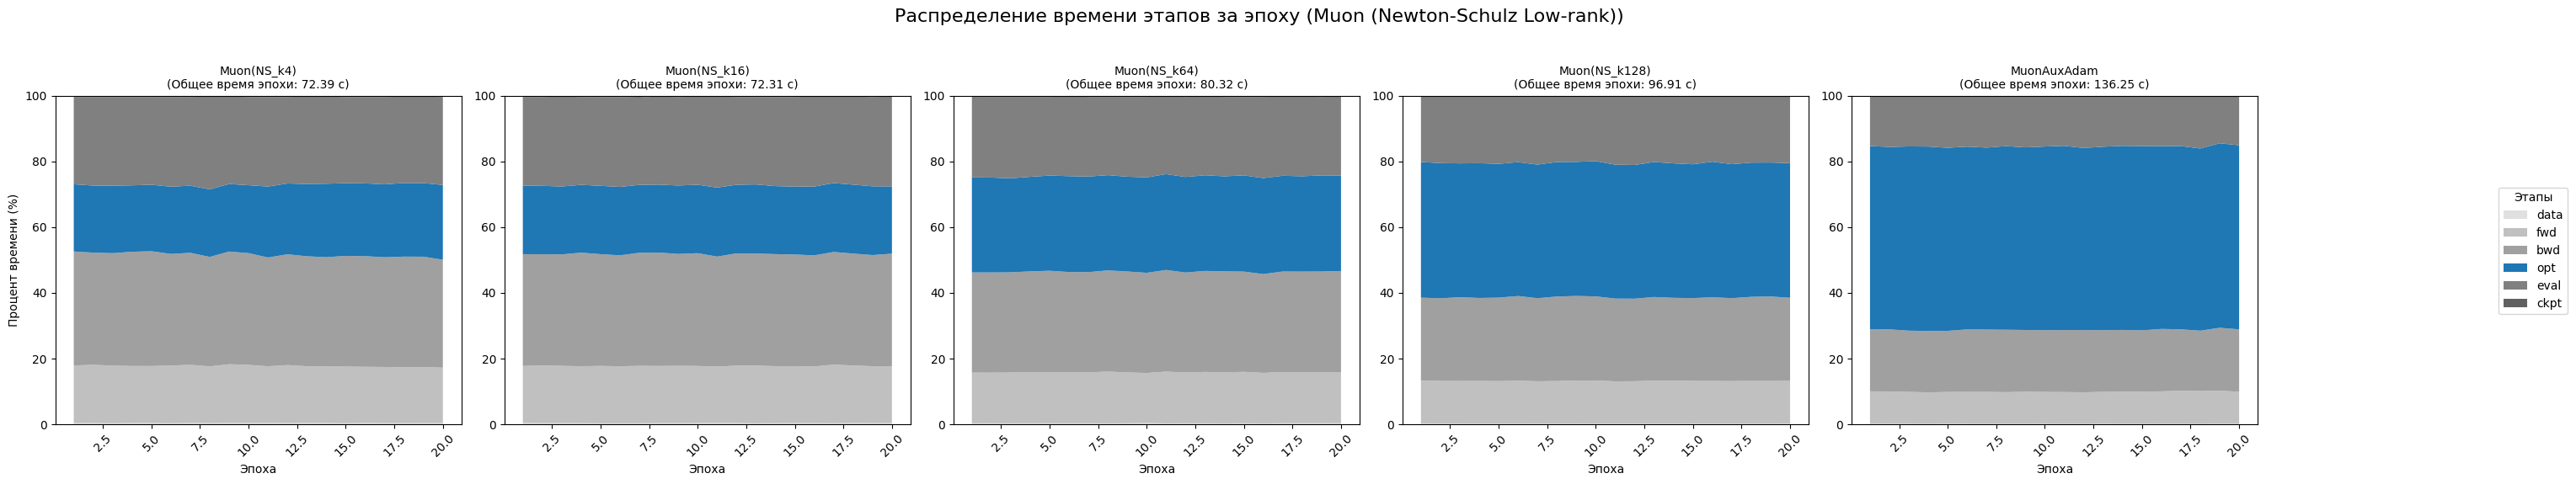

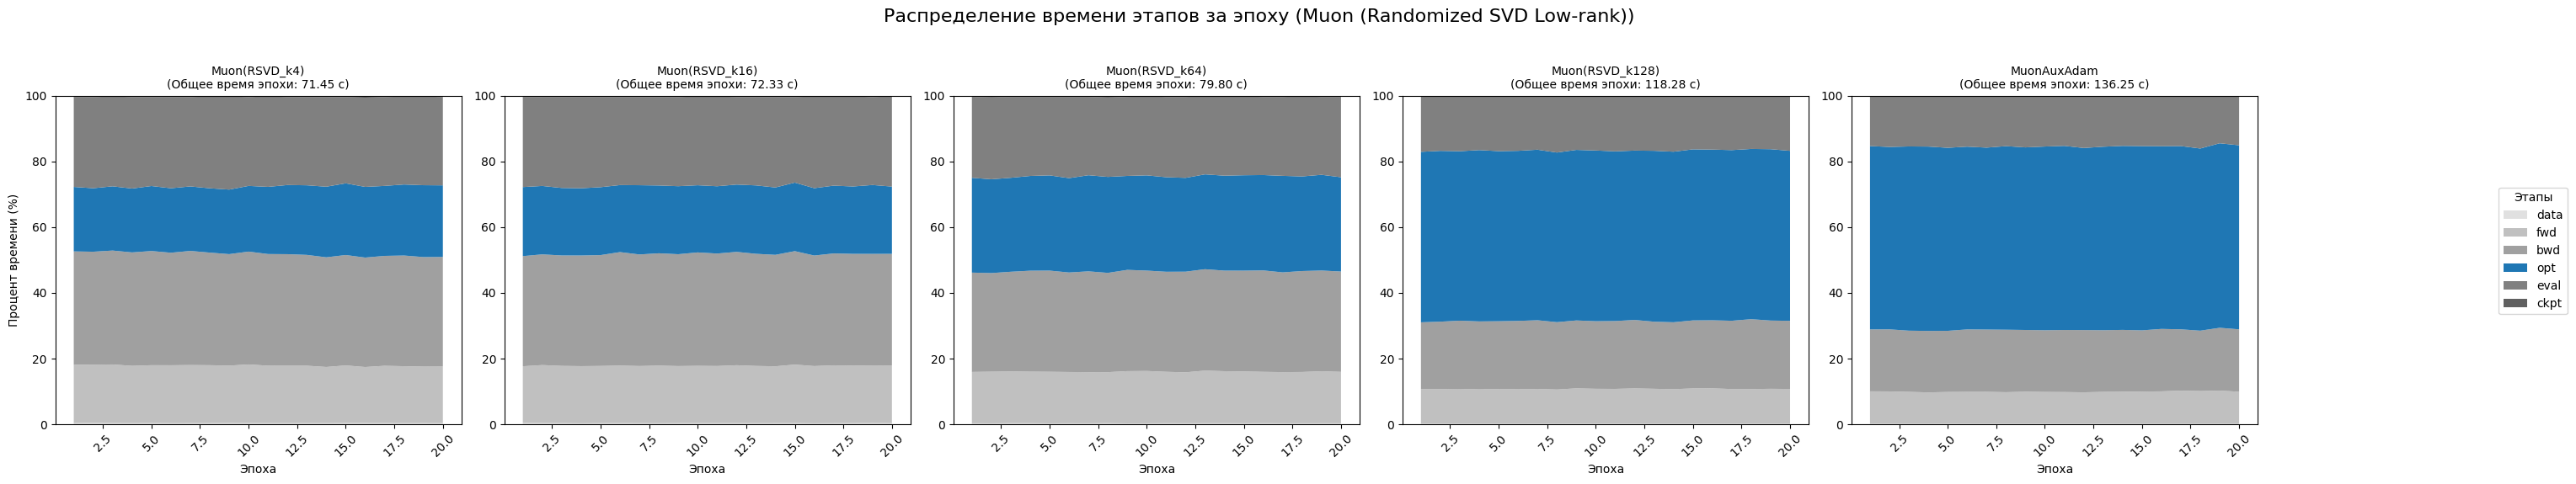

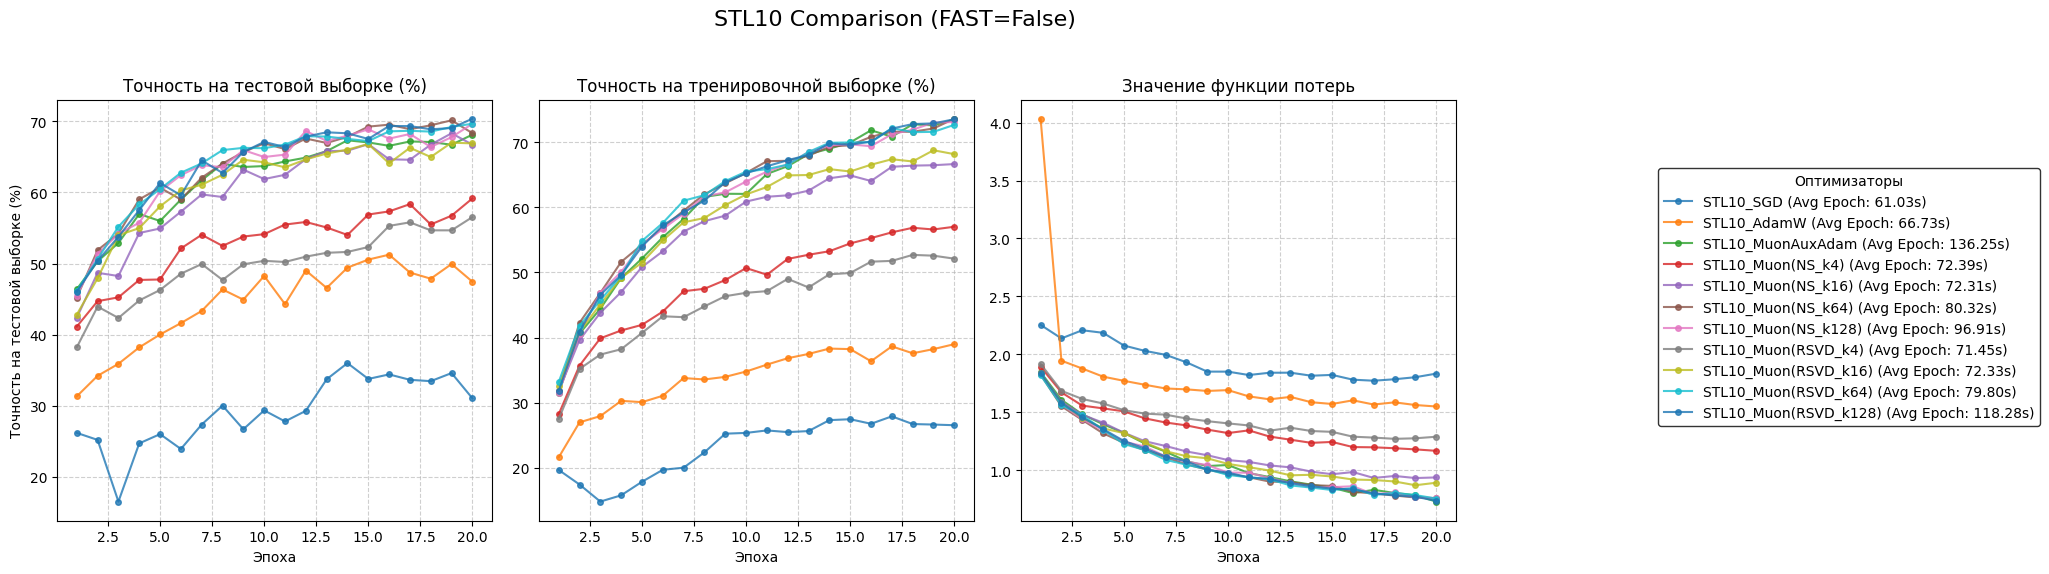

In [28]:
for ds in datasets_to_run:
    # # Показываем результаты после каждого датасета
    # plot_results(results_for_ds, title_prefix=f"{ds.upper()} (FAST={FAST})")
    
    # 1. Диаграммы с накоплением для MuonAuxAdam и Muon с NS
    ns_optimizers_to_plot = [f"Muon(NS_k{k})" for k in MUON_K_GRID]
    plot_stacked_time_per_stage(
        all_results, 
        [f"{opt}" for opt in ns_optimizers_to_plot] + [f"MuonAuxAdam"], # Передаем только часть имени оптимизатора
        ds.upper(), # Передаем название датасета для очистки
        "Muon (Newton-Schulz Low-rank)"
    )

    # 2. Диаграммы с накоплением для MuonAuxAdam и Muon с RSVD
    rsvd_optimizers_to_plot = [f"Muon(RSVD_k{k})" for k in MUON_K_GRID]
    plot_stacked_time_per_stage(
        all_results, 
        [f"{opt}" for opt in rsvd_optimizers_to_plot] + [f"MuonAuxAdam"], # Передаем только часть имени оптимизатора
        ds.upper(), # Передаем название датасета для очистки
        "Muon (Randomized SVD Low-rank)"
    )

    # 3. Полотно с тремя графиками (accuracy, test_accuracy, loss)
    plot_comparison_metrics(all_results, title_prefix=f"{ds.upper()} Comparison (FAST={FAST})")